# Milestone 2, step 2b — the per-pixel change map

`render_change_map.py` computes, for every 10 m pixel, normalised greenness in 2026 minus normalised
greenness in 2019, with each year normalised by the city-wide mean the hex ranking uses, and mapped
water masked. Only a picture of it comes down (`results/m2_change_map.png`, about 18 m a pixel).

1. **Does the map agree with the table?** Averaged over a hex, the per-pixel change must give back
   that hex's end-minus-start in `m2_hex_table_masked.csv`, because a mean of differences is a
   difference of means. Checked on the 40 biggest losses and 60 random hexes.
2. **The whole study area**, with the 40 biggest losses outlined by their photo-check verdict.
3. **Three places at full 10 m resolution:** the Shivaram Karanth Layout and the development east of
   Whitefield (the two largest loss clusters), and Lalbagh, which should show almost nothing.

Brown is a loss of greenness relative to the city, teal a gain, on a fixed ±0.3 scale.

**Needs Earth Engine** for sections 1 and 3.

In [1]:
import io
import json
import os
import socket
import urllib.parse
import urllib.request
from pathlib import Path

import ee
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from shapely.geometry import Point, box as shapely_box, shape

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO)
import sys
sys.path.insert(0, str(REPO))
from measure_hexes import MASKED_CLASSES
from render_change_map import CHANGE_RANGE, END, PALETTE, START, change_image

INK = "#2b2b2b"
LAND_CUTOFF = 0.25
TOP = 40
RGB_MAX = 3000
VERDICT_COLOURS = {"real loss": "#000000", "real loss, wetland": "#6a3d9a", "lake works": "#1f78b4",
                   "doubtful": "#ff7f00", "artefact": "#e31a1c"}

old = pd.read_csv("results/m2_hex_table.csv")
table = pd.read_csv("results/m2_hex_table_masked.csv")
green = table.pivot(index="h3", columns="year", values="green")
year_mean = green.mean(axis=0)
norm = green.sub(year_mean, axis=1)
change = norm[END] - norm[START]
land = table.groupby("h3").n_pixels.median() / old.groupby("h3").n_pixels.median()
ranked = change[land.reindex(change.index) >= LAND_CUTOFF]
losses = ranked.nsmallest(TOP).index
verdicts = pd.read_csv("results/m2_loss_verdicts.csv").set_index("h3")
assert list(verdicts.index) == list(losses), "verdicts are not for the current top 40"

grid = gpd.read_file("data/hex_grid.geojson").set_index("h3")
study = gpd.read_file("data/study_boundary.geojson")
water = gpd.read_file("data/osm_water.geojson")
water = water[water["class"].isin(MASKED_CLASSES)]
cache = json.loads(Path("data/place_names.json").read_text())

socket.setdefaulttimeout(120)
ee.Initialize(project=os.environ["EE_PROJECT"])
ee.data.setDeadline(120_000)


def retry(fetch, tries=4):
    for attempt in range(tries):
        try:
            return fetch()
        except Exception as exc:
            if attempt == tries - 1:
                raise
            print(f"  retrying after {type(exc).__name__}")


print(f"city-wide mean greenness {START} {year_mean[START]:.4f}, {END} {year_mean[END]:.4f}; Earth Engine ready")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


city-wide mean greenness 2019 0.2627, 2026 0.2870; Earth Engine ready


---
## 1 — Does the map agree with the table?

For each hex, the per-pixel change image is averaged with the same reducer, scale and water
polygons as `measure_hexes.py --mask-water` (the exact outlines here, not the simplified ones the
picture uses). The result should equal the table's end-minus-start.

In [2]:
sample = losses.append(ranked.drop(losses).sample(60, random_state=3).index)
cells = grid.loc[sample]
fc = ee.FeatureCollection([ee.Feature(ee.Geometry(g.__geo_interface__), {"h3": h})
                           for h, g in cells.geometry.items()])
local_water = water[water.intersects(cells.union_all())]
image = change_image(fc.geometry(), year_mean, local_water)
res = retry(image.reduceRegions(collection=fc, reducer=ee.Reducer.mean(), scale=10, tileScale=4).getInfo)
from_map = pd.Series({f["properties"]["h3"]: f["properties"].get("mean") for f in res["features"]})
gap = (from_map - change[sample]).abs()
print(f"{len(sample)} hexes (40 losses + 60 random): largest gap between map and table {gap.max():.2e}, "
      f"median {gap.median():.2e}")
print(pd.DataFrame({"table": change[losses[:5]], "map": from_map[losses[:5]]}).round(5).to_string())

100 hexes (40 losses + 60 random): largest gap between map and table 1.98e-05, median 7.36e-16
                   table      map
h3                               
88618921a3fffff -0.22567 -0.22567
8861892c69fffff -0.22094 -0.22094
88618921b5fffff -0.19756 -0.19756
8860169685fffff -0.19548 -0.19548
8861892c61fffff -0.18035 -0.18035


---
## 2 — The whole study area

Solid line: the study area. Dashed: the GBA city boundary. Grey: mapped water, masked as in the table. Each of the 40 biggest losses is outlined
in the colour of its photo-check verdict (`m2_loss_photo_check.ipynb`).

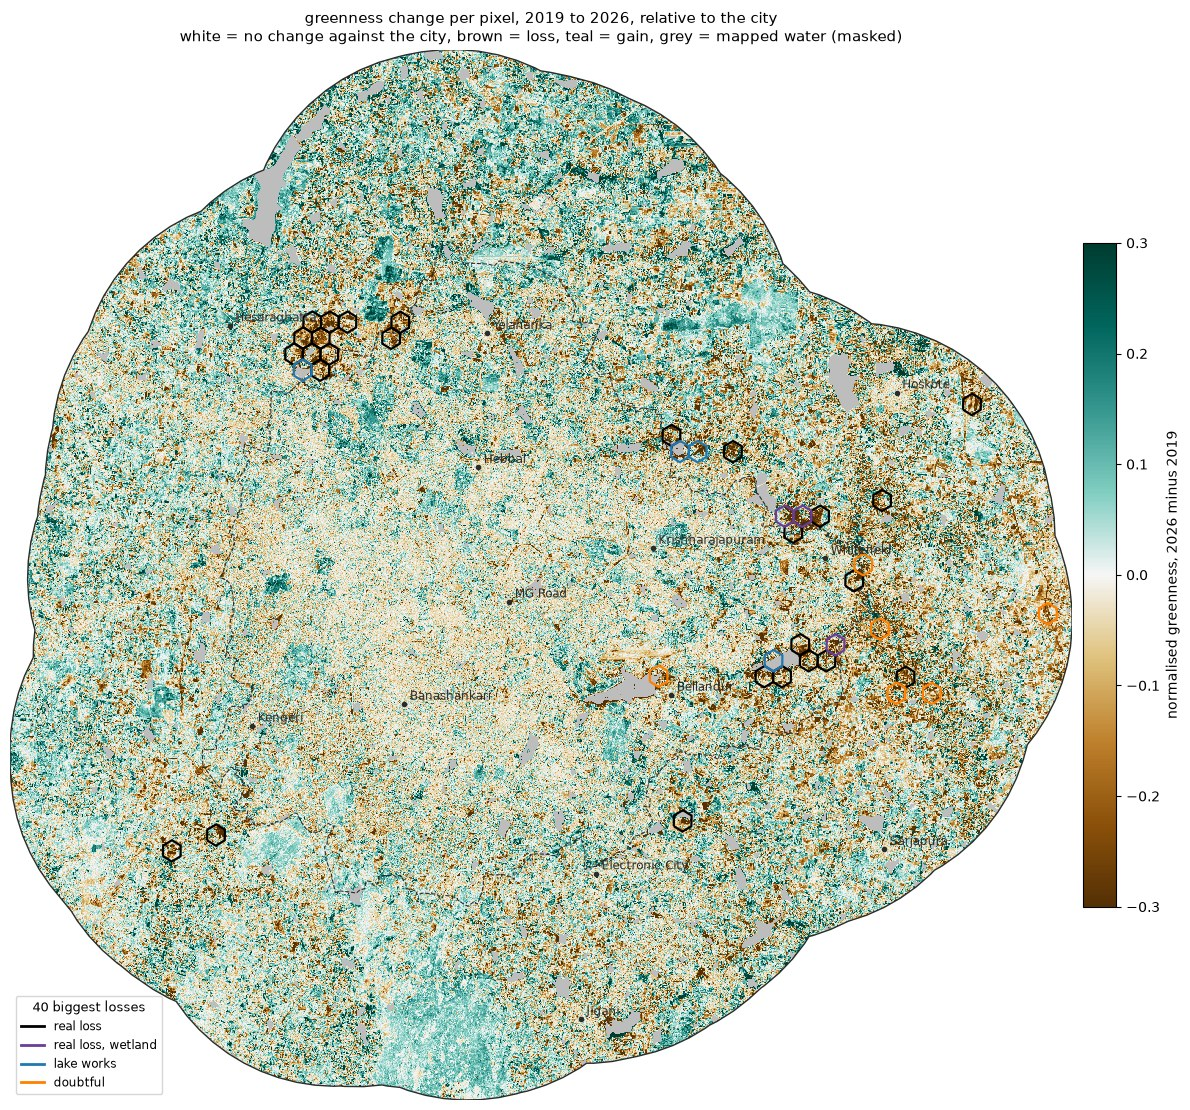

In [3]:
picture = plt.imread("results/m2_change_map.png")
w, s, e, n = study.total_bounds
gba = shape(cache["lookup?osm_ids=R7902476&format=json&polygon_geojson=1"][0]["geojson"])
marks = []
for key, hits in cache.items():
    if key.startswith("search?") and hits:
        hit = hits[0]
        if hit["class"] in ("place", "boundary", "landuse") or hit["type"] == "station":
            pt = Point(float(hit["lon"]), float(hit["lat"]))
            if study.contains(pt).any():
                marks.append((urllib.parse.parse_qs(key.split("?", 1)[1])["q"][0].split(",")[0], pt))

fig, ax = plt.subplots(figsize=(12, 13))
study.plot(ax=ax, color="#bdbdbd", zorder=0)
ax.imshow(picture, extent=(w, e, s, n), interpolation="none")
study.boundary.plot(ax=ax, color=INK, linewidth=1)
gpd.GeoSeries([gba]).boundary.plot(ax=ax, color=INK, linewidth=0.8, linestyle="--")
for verdict, colour in VERDICT_COLOURS.items():
    ids = verdicts.index[verdicts.verdict == verdict]
    if len(ids):
        grid.loc[ids].boundary.plot(ax=ax, color=colour, linewidth=1.6)
for name, pt in marks:
    ax.plot(pt.x, pt.y, "o", color=INK, markersize=3)
    ax.annotate(name, (pt.x, pt.y), xytext=(4, 3), textcoords="offset points", fontsize=8.5, color=INK)
ax.set_xlim(w, e); ax.set_ylim(s, n)
ax.set_aspect(1 / np.cos(np.radians((s + n) / 2)))
ax.set_axis_off()
cmap = LinearSegmentedColormap.from_list("change", PALETTE)
bar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(-CHANGE_RANGE, CHANGE_RANGE)),
                   ax=ax, fraction=0.03, pad=0.01)
bar.set_label(f"normalised greenness, {END} minus {START}")
ax.legend(handles=[Line2D([], [], color=c, linewidth=2, label=v) for v, c in VERDICT_COLOURS.items()
                   if (verdicts.verdict == v).any()],
          loc="lower left", fontsize=8.5, frameon=True, title="40 biggest losses", title_fontsize=9)
ax.set_title(f"greenness change per pixel, {START} to {END}, relative to the city\n"
             "white = no change against the city, brown = loss, teal = gain, grey = mapped water (masked)", fontsize=11)
plt.tight_layout(); plt.show()

---
## 3 — Three places at full resolution

Each window is about 3.3 km across at 10 m a pixel: the 2019 photo, the 2026 photo, and the change
map. Hexes from the loss list are outlined in yellow.

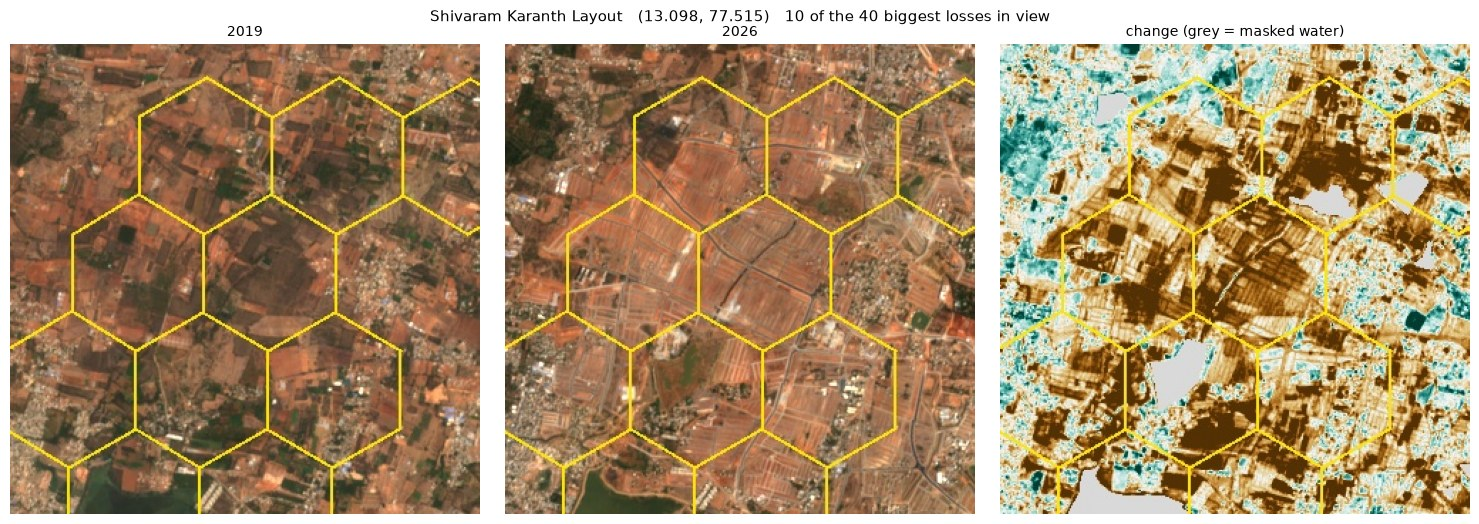

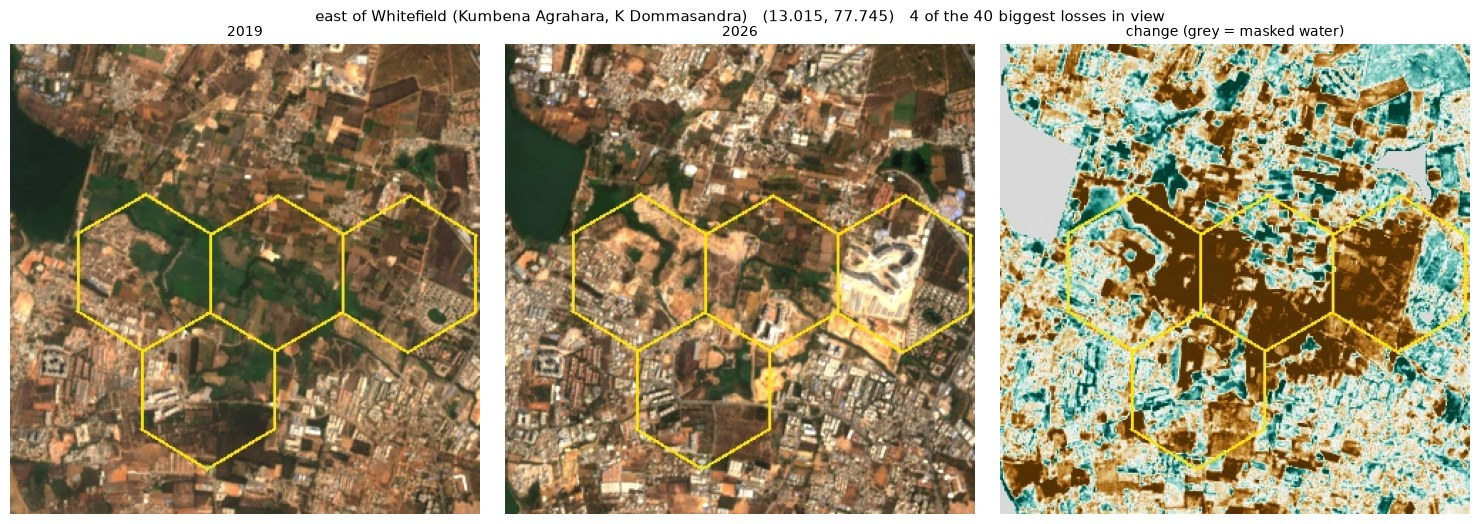

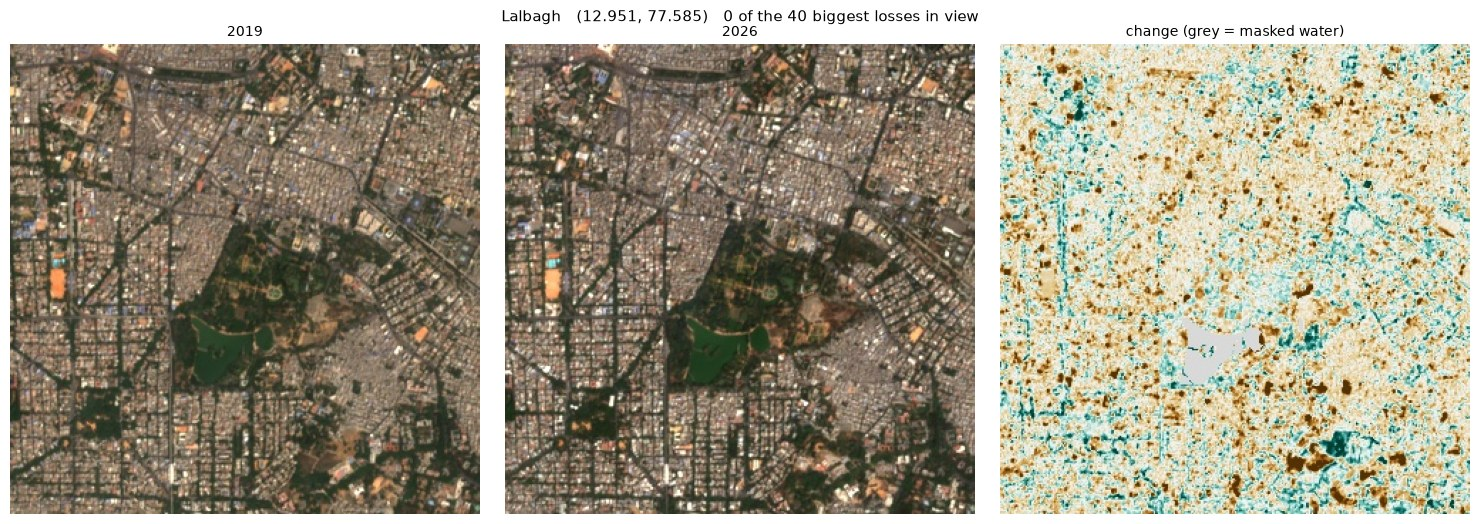

In [4]:
PLACES = {
    "Shivaram Karanth Layout": (13.098, 77.515),
    "east of Whitefield (Kumbena Agrahara, K Dommasandra)": (13.015, 77.745),
    "Lalbagh": (12.9507, 77.5848),
}
HALF = 0.015


def composite(year, region):
    return (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterBounds(region)
            .filterDate(f"{year}-02-01", f"{year}-03-31").median())


def thumb(image, region, fmt, px=330):
    def fetch():
        url = image.getThumbURL({"region": region, "dimensions": px, "format": fmt})
        return plt.imread(io.BytesIO(urllib.request.urlopen(url).read()), format=fmt)
    return retry(fetch)


for name, (lat, lng) in PLACES.items():
    window = shapely_box(lng - HALF, lat - HALF, lng + HALF, lat + HALF)
    region = ee.Geometry.Rectangle([lng - HALF, lat - HALF, lng + HALF, lat + HALF])
    listed = grid.loc[losses][grid.loc[losses].intersects(window)]
    edge = (ee.Image().byte().paint(ee.FeatureCollection([ee.Feature(ee.Geometry(g.__geo_interface__))
                                                         for g in listed.geometry]), 1, 2)
            .selfMask().visualize(palette=["#ffe600"])) if len(listed) else None
    pictures = []
    for year in (START, END):
        rgb = composite(year, region).visualize(bands=["B4", "B3", "B2"], min=0, max=RGB_MAX)
        pictures.append(rgb.blend(edge) if edge else rgb)
    diff = (ee.Image.constant(0).visualize(palette=["#d9d9d9"])
            .blend(change_image(region, year_mean, water[water.intersects(window)])
                   .visualize(min=-CHANGE_RANGE, max=CHANGE_RANGE, palette=PALETTE)))
    pictures.append(diff.blend(edge) if edge else diff)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.3))
    for ax, img, title in zip(axes, pictures, (f"{START}", f"{END}", "change (grey = masked water)")):
        ax.imshow(thumb(img, region, "jpg"))
        ax.set_title(title, fontsize=10)
        ax.set_axis_off()
    fig.suptitle(f"{name}   ({lat:.3f}, {lng:.3f})   {len(listed)} of the {TOP} biggest losses in view",
                 fontsize=11)
    plt.tight_layout(); plt.show()

---
## What this shows

**The per-pixel map and the hex table are the same measurement.** Averaged over 100 hexes, the map
gives back the table's end-minus-start with a median gap of 7e-16 and a largest gap of 2e-5, a
hundred times smaller than the smallest difference the ranking reports (section 1). So the picture
can be shown beside the ranking without a second method to explain.

**The losses are the biggest solid brown patches on the map.** The Shivaram Karanth Layout north of
Yelahanka and the development east of Whitefield read as solid brown at 10 m, with the photos
behind them (section 3). The orange (doubtful) hexes sit in a looser brown belt on the east fringe,
Hoskote to Sarjapura, which is farmland.

**Three things the picture does that the ranking doesn't, and that the site must caption:**

1. **The core reads faintly brown.** Built-up pixels barely respond to a wetter year, so against a
   city that averaged +0.024 greener in 2026 they come out slightly negative. By hex greenness
   decile, the mean change runs from −0.014 (least green) to +0.019 (greenest), a tenth of the
   colour scale and far below the losses (−0.10 to −0.23). This is the flat-subtraction limit logged
   2026-09-20. Without a caption it reads as "the whole core lost green".
2. **The fringe is speckled.** Single fields flip between brown and teal with the crop calendar. A
   pixel or a single field means nothing on its own; hex averages and large solid patches do. The
   hex layer should be the default view, with the pixel layer as texture underneath.
3. **Large teal areas, mostly in the south towards Jigani and the north-west.** These are gains
   relative to the city. The gains list has not been photo-checked, so none of them is a claim yet.

Lalbagh, the control, is pale with single-pixel speckle of about ±0.1 and no pattern. That is the
noise floor a reader should hold the brown patches against.

The PNG (`results/m2_change_map.png`, about 18 m a pixel) is gitignored and regenerates with
`python render_change_map.py`. The endpoint rasters for the site are milestone 5.